In [16]:
#install
%pip install pandas
%pip install matplotlib
%pip install numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Import pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Read in data
out_2023 = pd.read_csv(r'..\data\Outage_Dataset\eaglei_outages_with_events_2023.csv')
#Create DataFrame
df = pd.DataFrame(out_2023)
df.describe().round(2)

#Clean Data
df = df.drop('fips', axis=1)  #Drop redundant county code
df['Event Type'].fillna("Unknown", inplace=True) # Unknown Event Types
df.head()
df['Event Type'].isnull().sum()

np.int64(0)

Figure out how to parse Event Types

In [ ]:
human_list = ["attack","suspicious","theft","vandalism"]
#unknown_list = ["unknown","other"]
def parse_event(event):
    event = pd.Series(event.lower())
    if event.str.contains("failure").any():
        return "System Failure"
    if event.str.contains("weather").any():
        return "Weather"
    for intervention in human_list:
        if event.str.contains(intervention).any():
            return "Human Intervention"
    else:
        return "Unknown"
df['Event']=df['Event Type'].apply(parse_event)


,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,state,county,start_time,duration,end_time,min_customers,max_customers,mean_customers,Event
0,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Autauga,2023-01-12 19:00:00,52.00,2023-01-14 23:00:00,216,6873,1259.716346,Weather
1,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Baldwin,2023-01-12 15:45:00,1.25,2023-01-12 17:00:00,239,716,340.800000,Weather
2,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Baldwin,2023-01-12 19:15:00,3.00,2023-01-12 22:15:00,251,1107,557.916667,Weather
3,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Bibb,2023-01-13 04:00:00,7.25,2023-01-13 11:15:00,430,525,448.827586,Weather
4,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Blount,2023-01-12 16:30:00,3.50,2023-01-12 20:00:00,204,778,413.571429,Weather


In [74]:
df['Event'].unique()

array(['Weather', 'Human Intervention', 'Unknown', 'System Failure'],
      dtype=object)

In [3]:
#Create DataFrame
df = pd.DataFrame(out_2023)
df.describe().round(2)

,duration,min_customers,max_customers,mean_customers
count,77341.00,77341.00,77341.00,77341.00
mean,6.34,531.49,1653.96,913.39
std,15.46,1111.93,6589.02,2547.77
min,0.25,200.00,200.00,200.00
25%,0.50,220.00,285.00,267.20
50%,1.50,278.00,513.00,430.00
75%,3.75,474.00,1291.00,863.10
max,193.25,60581.00,348829.00,289849.33


In [69]:
df.dtypes

event_id                 object
state_event              object
Datetime Event Began     object
Datetime Restoration     object
Event Type               object
state                    object
county                   object
start_time               object
duration                float64
end_time                 object
min_customers             int64
max_customers             int64
mean_customers          float64
Event                    object
dtype: object

In [5]:
#Group and Aggregate
grp = df.groupby(['duration'])
#print(grp.first())
agg_df = df.groupby(['duration','state','county','max_customers']).agg(
    total_duration=('duration','sum'),
    avg_duration=('duration','mean')
)
print(agg_df)

                                             total_duration  avg_duration
duration state     county     max_customers                              
0.25     Alabama   Autauga    358                      0.25          0.25
                   Baldwin    272                      0.25          0.25
                              295                      0.25          0.25
                              341                      0.25          0.25
                   Calhoun    2552                     0.25          0.25
...                                                     ...           ...
136.00   Texas     Leon       6631                  4624.00        136.00
162.00   Tennessee Shelby     138851                 162.00        162.00
174.75   Texas     Williamson 70703                 5766.75        174.75
178.75   Texas     Travis     185025                5898.75        178.75
193.25   Michigan  Macomb     6189                   193.25        193.25

[21423 rows x 2 columns]


In [11]:
df['Event Type'].unique()

array(['Severe Weather', '- Weather or natural disaster',
       'Actual Physical Attack/Vandalism', 'Transmission Interruption',
       'System Operations', 'Suspicious Activity',
       '- Vandalism - Suspicious activity', '- Vandalism',
       '- Unknown - Vandalism', '- Vandalism - Theft', '- Other',
       'Vandalism', '- Fuel supply emergency', '- Unknown', '- Theft',
       '- Theft - Other', 'Cyber Event', '- Vandalism\xa0- Theft',
       '- Failure at high voltage substation or switchyard',
       '- Physical attack\xa0- Vandalism\xa0- Suspicious activity',
       '- Suspicious activity', '- Transmission equipment failure',
       '- Threat of physical attack',
       'Weather or natural disaster - Other',
       '- Vandalism - Theft - Suspicious activity',
       '- Failure at high voltage substation or switchyard\xa0- Weather or natural disaster',
       '- Theft - Suspicious activity',
       '- Physical attack - Generator loss or failure',
       '- Unknown\xa0- Failure at

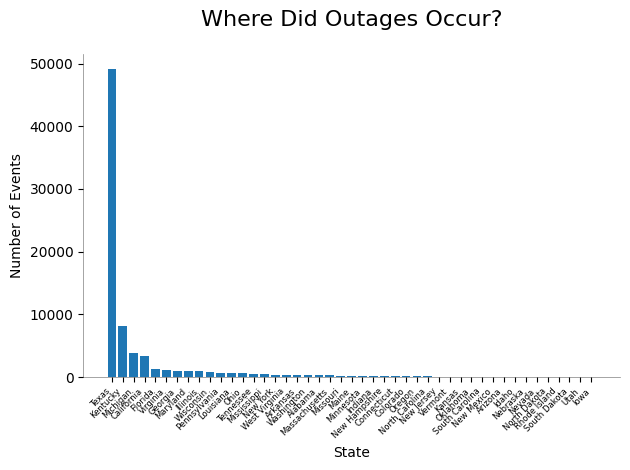

In [14]:
state_counts = df["state"].value_counts().sort_values(ascending=False)
plt.bar(state_counts.index,state_counts.values)
plt.xticks(rotation=45, ha="right", fontsize=6)
#plt.figure(figsize=(10,6))
plt.xlabel("State")
plt.ylabel("Number of Events")
plt.title("Where Did Outages Occur?", fontsize=16, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/EventsPerStateBarPlot.png")
plt.show()

In [11]:
df['state'].unique()
df['state'].value_counts()

state
Texas             49096
Kentucky           8100
Michigan           3815
California         3369
Florida            1356
Virginia           1159
Georgia            1022
Maryland            940
Illinois            935
Wisconsin           774
Pennsylvania        633
Louisiana           606
Ohio                602
Tennessee           483
Mississippi         447
New York            384
West Virginia       353
Arkansas            353
Washington          309
Alabama             296
Massachusetts       259
Missouri            239
Maine               220
Minnesota           162
Indiana             154
New Hampshire       140
Connecticut         136
Colorado            126
Oregon              119
North Carolina       96
New Jersey           89
Vermont              81
Kansas               76
Oklahoma             72
South Carolina       68
New Mexico           52
Arizona              48
Idaho                36
Nebraska             26
Nevada               24
North Dakota         22
Rhode Isla

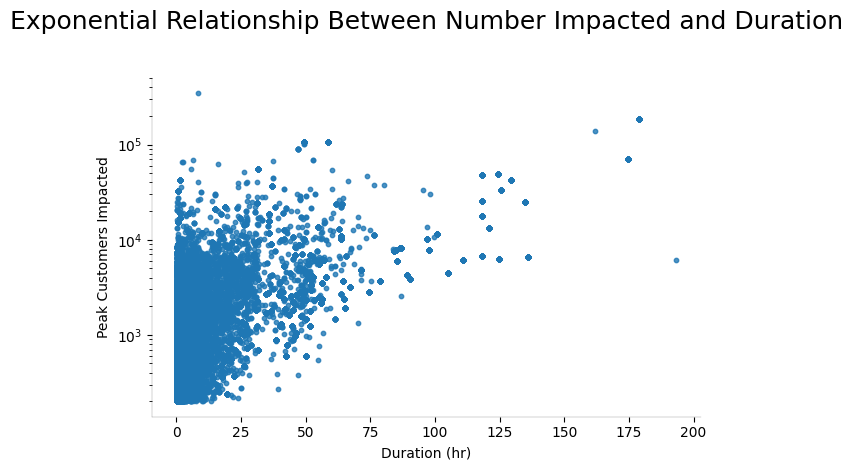

In [12]:
plt.Figure(figsize=(10,6))

#

#colors = ["#18AF75" if genre == featured_genre else "#FFF6F6" for genre in spotify_df["Genre"]] 

plt.scatter(
            df["duration"], 
            df["max_customers"],
            #color = colors,
            alpha = 0.8,
            s = 10
            )
            
plt.xlabel("Duration (hr)")
plt.ylabel("Peak Customers Impacted")
#plt.title("No Apparent Correlation Between Monthly Listens and Total Streams")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title("Exponential Relationship Between Number Impacted and Duration", fontsize = 18, pad=35)

for spine in ax.spines.values():
    spine.set_linewidth(0.25)
    spine.set_alpha(0.5)
plt.tight_layout()
plt.savefig("../plots/NumberImpactedVDuration.png")
plt.show()

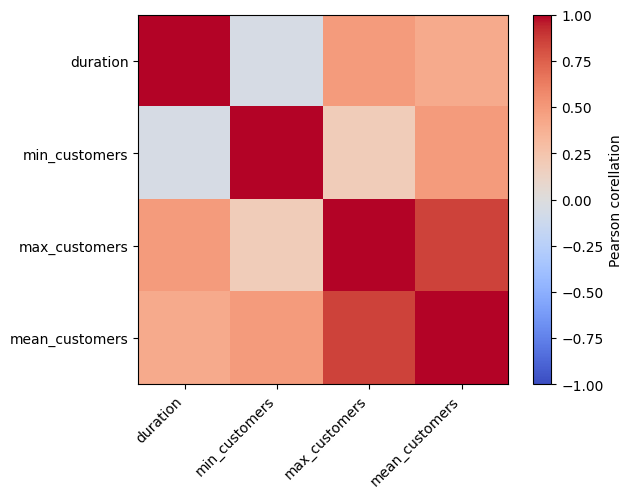

In [18]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

im = plt.imshow(corr, vmin=-1,vmax=1, cmap='coolwarm')
plt.colorbar(im, label="Pearson corellation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.savefig("../plots/Heatmap.png")
plt.show()